In [6]:
import numpy as np
import pandas as pd 
import csv
import os
import re
import matplotlib.pyplot as plt
import datetime


In [16]:
folder_location="./Sales_Data"

In [18]:
os.walk(folder_location)

<generator object walk at 0x16aeaa9f0>

In [20]:
for base_folder,sub_folders,files in os.walk(folder_location):
    print(base_folder)
    print(sub_folders)
    print(files)

/Users/mohitverma/Downloads/Sales_Data
[]
['Sales_December_2019.csv', 'Sales_April_2019.csv', 'Sales_February_2019.csv', 'Sales_March_2019.csv', 'Sales_August_2019.csv', 'Sales_May_2019.csv', 'Sales_November_2019.csv', 'Sales_October_2019.csv', 'Sales_January_2019.csv', 'Sales_September_2019.csv', 'Sales_July_2019.csv', 'Sales_June_2019.csv']


In [22]:
files=[os.path.join(folder_location,f) for f in os.listdir(folder_location) if f.endswith(".csv")]

In [14]:
final_df=pd.DataFrame()
print(final_df.shape)
for f in files:
    df=pd.read_csv(f)
    final_df=pd.concat([final_df,df])
    print(f,df.shape,final_df.shape)

final_df.to_csv('merged_sales_data.csv', index=False)
    

(0, 0)
/Users/mohitverma/Downloads/Sales_Data/Sales_December_2019.csv (25117, 6) (25117, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_April_2019.csv (18383, 6) (43500, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_February_2019.csv (12036, 6) (55536, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_March_2019.csv (15226, 6) (70762, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_August_2019.csv (12011, 6) (82773, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_May_2019.csv (16635, 6) (99408, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_November_2019.csv (17661, 6) (117069, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_October_2019.csv (20379, 6) (137448, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_January_2019.csv (9723, 6) (147171, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_September_2019.csv (11686, 6) (158857, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_July_2019.csv (14371, 6) (173228, 6)
/Users/mohitverma/Downloads/Sales_Data/Sales_June_2019.csv (13622, 6) (1

In [16]:
final_df.head(3)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,295665,Macbook Pro Laptop,1,1700,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.0,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"


In [18]:
final_df.shape

(186850, 6)

In [20]:
final_df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,295665,Macbook Pro Laptop,1,1700,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.0,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


In [22]:
final_df.duplicated().sum()

1162

In [24]:
final_df.loc[(final_df.duplicated(keep=False)), :].sort_values(["Order ID"])


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
874,142071,AA Batteries (4-pack),1,3.84,01/17/19 23:02,"131 2nd St, Boston, MA 02215"
875,142071,AA Batteries (4-pack),1,3.84,01/17/19 23:02,"131 2nd St, Boston, MA 02215"
4125,145143,Lightning Charging Cable,1,14.95,01/06/19 03:01,"182 Jefferson St, San Francisco, CA 94016"
4126,145143,Lightning Charging Cable,1,14.95,01/06/19 03:01,"182 Jefferson St, San Francisco, CA 94016"
5810,146765,Google Phone,1,600,01/21/19 11:23,"918 Highland St, New York City, NY 10001"
...,...,...,...,...,...,...
12567,NaN,NaN,NaN,NaN,NaN,NaN
12640,NaN,NaN,NaN,NaN,NaN,NaN
12659,NaN,NaN,NaN,NaN,NaN,NaN
12732,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
final_df.isna().sum(axis=0)

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [28]:
final_df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,295665,Macbook Pro Laptop,1,1700,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.0,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


In [30]:
final_df.loc[(final_df['Order ID'].isna()),:]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
264,NaN,NaN,NaN,NaN,NaN,NaN
648,NaN,NaN,NaN,NaN,NaN,NaN
680,NaN,NaN,NaN,NaN,NaN,NaN
1385,NaN,NaN,NaN,NaN,NaN,NaN
1495,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
12567,NaN,NaN,NaN,NaN,NaN,NaN
12640,NaN,NaN,NaN,NaN,NaN,NaN
12659,NaN,NaN,NaN,NaN,NaN,NaN
12732,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
final_df.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

In [36]:
final_df.dropna( how='all', inplace=True)

In [38]:
final_df.isna().sum(axis=0)

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

In [40]:
final_df.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object

In [42]:
final_df.head(2)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,295665,Macbook Pro Laptop,1,1700,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.0,12/29/19 07:03,"562 2nd St, New York City, NY 10001"


In [44]:
#to convert all the column names to lower case and replace the space with _
final_df.columns=final_df.columns.str.lower().str.replace(" ","_")

In [46]:
final_df.head(5)

,order_id,product,quantity_ordered,price_each,order_date,purchase_address
0,295665,Macbook Pro Laptop,1,1700,12/30/19 00:01,"136 Church St, New York City, NY 10001"
1,295666,LG Washing Machine,1,600.0,12/29/19 07:03,"562 2nd St, New York City, NY 10001"
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001"
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016"
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301"


In [48]:
final_df = final_df.loc[~(final_df['quantity_ordered'] == 'Quantity Ordered')]
                                                                                

In [50]:
final_df[final_df['quantity_ordered'] == 'Quantity Ordered'].head()


,order_id,product,quantity_ordered,price_each,order_date,purchase_address


In [52]:
final_df['quantity_ordered']=final_df['quantity_ordered'].astype(int)


In [54]:
final_df['price_each']=final_df['price_each'].astype(float)


In [56]:
final_df.dtypes

order_id             object
product              object
quantity_ordered      int64
price_each          float64
order_date           object
purchase_address     object
dtype: object

In [58]:
final_df.loc[(final_df.duplicated(keep=False)), :].sort_values(["order_id"]).head(10)


,order_id,product,quantity_ordered,price_each,order_date,purchase_address
875,142071,AA Batteries (4-pack),1,3.84,01/17/19 23:02,"131 2nd St, Boston, MA 02215"
874,142071,AA Batteries (4-pack),1,3.84,01/17/19 23:02,"131 2nd St, Boston, MA 02215"
4126,145143,Lightning Charging Cable,1,14.95,01/06/19 03:01,"182 Jefferson St, San Francisco, CA 94016"
4125,145143,Lightning Charging Cable,1,14.95,01/06/19 03:01,"182 Jefferson St, San Francisco, CA 94016"
5810,146765,Google Phone,1,600.00,01/21/19 11:23,"918 Highland St, New York City, NY 10001"
5811,146765,Google Phone,1,600.00,01/21/19 11:23,"918 Highland St, New York City, NY 10001"
6807,147707,Wired Headphones,1,11.99,01/04/19 16:50,"883 4th St, Dallas, TX 75001"
6806,147707,Wired Headphones,1,11.99,01/04/19 16:50,"883 4th St, Dallas, TX 75001"
8134,148984,USB-C Charging Cable,1,11.95,01/08/19 17:36,"562 14th St, Boston, MA 02215"
8133,148984,USB-C Charging Cable,1,11.95,01/08/19 17:36,"562 14th St, Boston, MA 02215"


In [60]:
final_df.duplicated().sum()

264

In [62]:
final_df[final_df.duplicated()]

,order_id,product,quantity_ordered,price_each,order_date,purchase_address
440,296081,Flatscreen TV,1,300.00,12/30/19 16:52,"970 Sunset St, Austin, TX 73301"
1735,297311,Bose SoundSport Headphones,1,99.99,12/07/19 07:30,"858 Willow St, Los Angeles, CA 90001"
2822,298358,Apple Airpods Headphones,1,150.00,12/04/19 15:57,"482 8th St, San Francisco, CA 94016"
3131,298657,Lightning Charging Cable,1,14.95,12/01/19 18:22,"428 12th St, Atlanta, GA 30301"
3377,298883,Wired Headphones,1,11.99,12/28/19 18:07,"516 Willow St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
9267,218756,AAA Batteries (4-pack),1,2.99,06/11/19 14:54,"362 Hickory St, Boston, MA 02215"
9538,219007,AA Batteries (4-pack),1,3.84,06/24/19 11:16,"42 8th St, Los Angeles, CA 90001"
10983,220392,Lightning Charging Cable,1,14.95,06/08/19 17:13,"472 8th St, Portland, ME 04101"
11487,220882,Lightning Charging Cable,1,14.95,06/13/19 17:53,"588 Lake St, Boston, MA 02215"


In [64]:
final_df.drop_duplicates(subset=final_df.columns,keep='first', inplace=True)

In [66]:
final_df[final_df.duplicated()]

,order_id,product,quantity_ordered,price_each,order_date,purchase_address


In [68]:
final_df['purchase_address']

0        136 Church St, New York City, NY 10001
1           562 2nd St, New York City, NY 10001
2          277 Main St, New York City, NY 10001
3           410 6th St, San Francisco, CA 94016
4                 43 Hill St, Atlanta, GA 30301
                          ...                  
13617             795 Pine St, Boston, MA 02215
13618     495 North St, New York City, NY 10001
13619     319 Ridge St, San Francisco, CA 94016
13620      916 Main St, San Francisco, CA 94016
13621            209 11th St, Atlanta, GA 30301
Name: purchase_address, Length: 185686, dtype: object

In [70]:
#to get the state name

final_df['state_name']=final_df['purchase_address'].str.split(", ").str[-1].str.split().str[0].str.strip()
final_df['state_name']


0        NY
1        NY
2        NY
3        CA
4        GA
         ..
13617    MA
13618    NY
13619    CA
13620    CA
13621    GA
Name: state_name, Length: 185686, dtype: object

In [72]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA


In [74]:
#to get the city name

final_df['city_name']=final_df['purchase_address'].str.split(",").str[1]
print(final_df['city_name'])

0         New York City
1         New York City
2         New York City
3         San Francisco
4               Atlanta
              ...      
13617            Boston
13618     New York City
13619     San Francisco
13620     San Francisco
13621           Atlanta
Name: city_name, Length: 185686, dtype: object


In [76]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY,New York City
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA,San Francisco
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA,Atlanta


In [78]:
#total Revenue by state
final_df['total_revenue']=final_df['quantity_ordered'] * final_df['price_each']
final_df.head(2)


,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name,total_revenue
0,295665,Macbook Pro Laptop,1,1700.0,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City,1700.0
1,295666,LG Washing Machine,1,600.0,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City,600.0


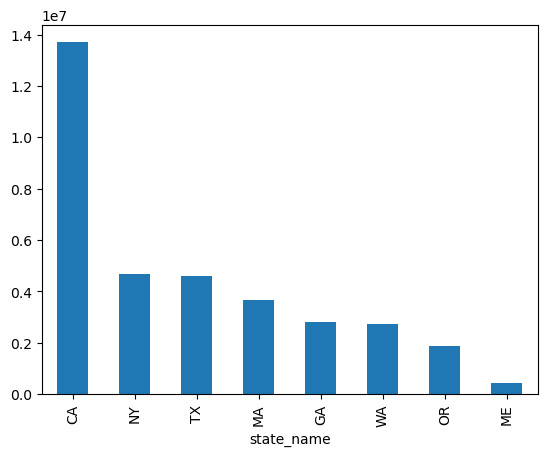

In [80]:
final_df.groupby(['state_name'])['total_revenue'].sum().sort_values(ascending=False).plot(kind="bar")
plt.show()


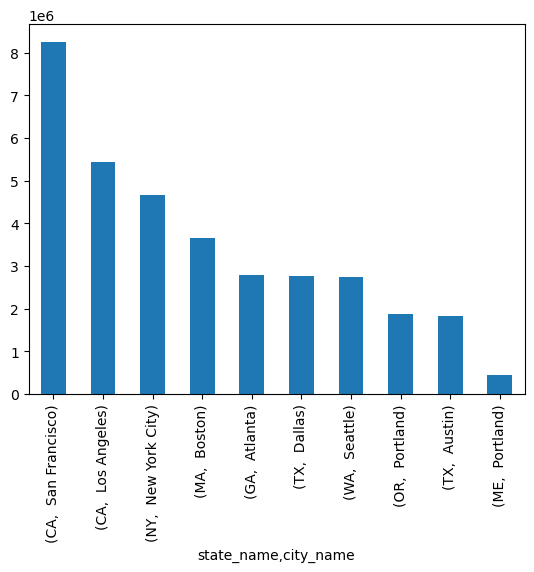

In [82]:
final_df.groupby(['state_name',
                 'city_name'])['total_revenue'].sum().sort_values(ascending=False).plot(kind="bar")
plt.show()

In [84]:
pd.DataFrame(final_df.groupby(['state_name',
                 'city_name'])['total_revenue'].sum()).reset_index()

,state_name,city_name,total_revenue
0,CA,Los Angeles,5448304.28
1,CA,San Francisco,8254743.55
2,GA,Atlanta,2794199.07
3,MA,Boston,3658627.65
4,ME,Portland,449321.38
5,NY,New York City,4661867.14
6,OR,Portland,1870010.56
7,TX,Austin,1818044.33
8,TX,Dallas,2765373.96
9,WA,Seattle,2745046.02


In [86]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name,total_revenue
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City,1700.00
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City,600.00
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY,New York City,11.95
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA,San Francisco,149.99
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA,Atlanta,11.95


In [88]:
import datetime

In [734]:
final_df['month']=(final_df['order_date'])

In [90]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name,total_revenue
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City,1700.00
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City,600.00
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY,New York City,11.95
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA,San Francisco,149.99
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA,Atlanta,11.95


In [94]:
final_df['date'] = final_df['order_date'].astype(str)

In [96]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name,total_revenue,date
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City,1700.00,12/30/19 00:01
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City,600.00,12/29/19 07:03
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY,New York City,11.95,12/12/19 18:21
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA,San Francisco,149.99,12/22/19 15:13
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA,Atlanta,11.95,12/18/19 12:38


In [98]:
final_df['month']=final_df['order_date'].str.split("/").str[0]

In [100]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name,total_revenue,date,month
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City,1700.00,12/30/19 00:01,12
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City,600.00,12/29/19 07:03,12
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY,New York City,11.95,12/12/19 18:21,12
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA,San Francisco,149.99,12/22/19 15:13,12
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA,Atlanta,11.95,12/18/19 12:38,12


In [115]:
final_df['date']=final_df['order_date'].str.split("/").str[1]

In [117]:
final_df['year']=final_df['order_date'].str.split("/").str[2].str.split(" ").str[0].astype(int)+2000

In [119]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name,total_revenue,date,month,year
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City,1700.00,30,12,2019
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City,600.00,29,12,2019
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY,New York City,11.95,12,12,2019
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA,San Francisco,149.99,22,12,2019
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA,Atlanta,11.95,18,12,2019


In [121]:
final_df['day_type'] = final_df.apply(
    lambda x: 'Weekend' if datetime.datetime(x['year'], int(x['month']), int(x['date'])).isoweekday() >= 6 else 'Weekday',
    axis=1
)

In [122]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name,total_revenue,date,month,year,day_type
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City,1700.00,30,12,2019,Weekday
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City,600.00,29,12,2019,Weekend
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY,New York City,11.95,12,12,2019,Weekday
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA,San Francisco,149.99,22,12,2019,Weekend
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA,Atlanta,11.95,18,12,2019,Weekday


In [125]:
final_df['hour']=final_df['order_date'].str.split("/").str[2].str.split(" ").str[1].str.split(":").str[0].astype(int)
print(final_df['hour'].astype (int))

0         0
1         7
2        18
3        15
4        12
         ..
13617    19
13618    19
13619    18
13620    18
13621    14
Name: hour, Length: 185686, dtype: int64


In [127]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name,total_revenue,date,month,year,day_type,hour
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City,1700.00,30,12,2019,Weekday,0
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City,600.00,29,12,2019,Weekend,7
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY,New York City,11.95,12,12,2019,Weekday,18
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA,San Francisco,149.99,22,12,2019,Weekend,15
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA,Atlanta,11.95,18,12,2019,Weekday,12


In [129]:
final_df['purchase_made_in']=final_df['hour'].apply(lambda x: "First Half of the Day" if x<=11 else "Second Half Of The Day")

In [131]:
final_df.head()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,state_name,city_name,total_revenue,date,month,year,day_type,hour,purchase_made_in
0,295665,Macbook Pro Laptop,1,1700.00,12/30/19 00:01,"136 Church St, New York City, NY 10001",NY,New York City,1700.00,30,12,2019,Weekday,0,First Half of the Day
1,295666,LG Washing Machine,1,600.00,12/29/19 07:03,"562 2nd St, New York City, NY 10001",NY,New York City,600.00,29,12,2019,Weekend,7,First Half of the Day
2,295667,USB-C Charging Cable,1,11.95,12/12/19 18:21,"277 Main St, New York City, NY 10001",NY,New York City,11.95,12,12,2019,Weekday,18,Second Half Of The Day
3,295668,27in FHD Monitor,1,149.99,12/22/19 15:13,"410 6th St, San Francisco, CA 94016",CA,San Francisco,149.99,22,12,2019,Weekend,15,Second Half Of The Day
4,295669,USB-C Charging Cable,1,11.95,12/18/19 12:38,"43 Hill St, Atlanta, GA 30301",GA,Atlanta,11.95,18,12,2019,Weekday,12,Second Half Of The Day


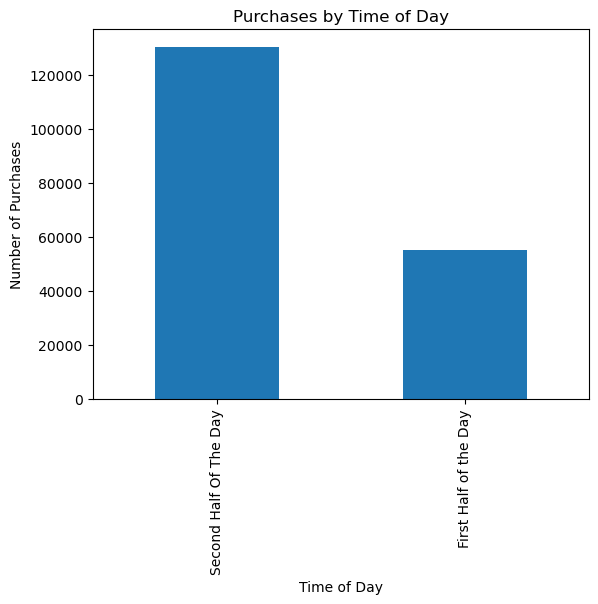

In [133]:
final_df['purchase_made_in'].value_counts().plot(kind='bar')
plt.xlabel("Time of Day")
plt.ylabel("Number of Purchases")
plt.title("Purchases by Time of Day")
plt.show()

In [135]:
final_df.to_csv('cleaned_sales_data.csv', index=False)